# Connectivity Benchmark Pipeline

**Tasks covered:**
1. Generate simulated connectivity data (`simulation_models.py`)
2. Run all effective-connectivity methods (`fc_pipeline.py`)
3. Verify methods against `ground_truth_dict` via MCC
4. Upgraded FC utilities (adaptive thresholding, binarization, PSI fix)

---
**Model index map:**

| Index | Name | Connectivity |
|---|---|---|
| 0 | random | x1→x2, x1→x3, x4→x5 |
| 1 | henon | x1→x2→x3, x4↔x5 |
| 2 | lorenz | x1→x2→x3→x4→x5 (chain) |
| 3 | sweep | x1→x2, x1→x3 (freq sweep) |
| 4 | cascadear | x1→x2→x3→x4, x5→x4 |
| 5 | pinkarlin | x1→x2,x3,x4; x5→x4 |
| 6 | pinkarnonlin | same as pinkarlin, nonlinear |
| 7 | freqarlin | x1→x2,x3,x4; x2→x3; x5→x4 |
| 8 | freqarnonlin | same as freqarlin, nonlinear |

## 0. Setup

In [1]:
%matplotlib inline

import sys
import os

# Add src/ and utils/ to path so project modules can be imported directly
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import matthews_corrcoef
import pickle
import warnings
warnings.filterwarnings('ignore')


FIGURES_DIR = os.path.abspath('../figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(name: str, dpi: int = 600) -> None:
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(FIGURES_DIR, f"{name}.{ext}"),
                    dpi=dpi, bbox_inches="tight")


from simulation.simulation_models import simulate, _MODEL_MAP
from simulation.ground_truth import GROUND_TRUTH
from methods.fc_pipeline import FCMethods
from metrics import binarize_matrix as binarize_fc


## 1. Generate Simulated Connectivity Data

Generate `N_SUBJECTS` subjects × `N_MODELS` models × `N_EPOCHS` epochs,  
each epoch is a `(N_NODES, T)` array.  
Seeds are fixed as `subj * 100 + model_id * 10 + epoch` for reproducibility.

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
N_SUBJECTS  = 25
N_EPOCHS    = 10
N_NODES     = 5
T           = 1000
FS          = 256       # sampling frequency (Hz)

MODEL_NAMES = list(_MODEL_MAP.keys())   # 9 models
# MODEL_NAMES = ['random', 'henon', 'lorenz', 'sweep', 'cascadear', 'freqarlin', 'freqarnonlin']
N_MODELS    = len(MODEL_NAMES)

print(f"Models ({N_MODELS}): {MODEL_NAMES}")

Models (9): ['random', 'henon', 'lorenz', 'sweep', 'cascadear', 'pinkarlin', 'pinkarnonlin', 'freqarlin', 'freqarnonlin']


In [ ]:
# ── Generate ──────────────────────────────────────────────────────────────────
# Shape: (subjects, models, epochs, nodes, time)
all_data = np.zeros((N_SUBJECTS, N_MODELS, N_EPOCHS, N_NODES, T), dtype=np.float32)

for subj in tqdm(range(N_SUBJECTS), desc="Subjects"):
    for model_id, model_name in enumerate(MODEL_NAMES):
        for epoch in range(N_EPOCHS):
            seed = subj * 100 + model_id * 10 + epoch
            signal = simulate(model=model_name, T=T, seed=seed)
            all_data[subj, model_id, epoch] = signal

print(f"Generated data shape: {all_data.shape}")

In [ ]:
# ── Validate: check NaN / Inf ─────────────────────────────────────────────────
invalid = []
for subj in range(N_SUBJECTS):
    for model_id in range(N_MODELS):
        for epoch in range(N_EPOCHS):
            d = all_data[subj, model_id, epoch]
            if np.isnan(d).any() or np.isinf(d).any():
                invalid.append((subj, MODEL_NAMES[model_id], epoch))

if invalid:
    print(f"Invalid entries ({len(invalid)}):")
    for entry in invalid[:10]:
        print(f"  subj={entry[0]}, model={entry[1]}, epoch={entry[2]}")
else:
    print("All data valid.")

In [ ]:
# ── Save ──────────────────────────────────────────────────────────────────────
save_path = os.path.join('..', 'data', 'simulated_connectivity_benchmark.npz')
np.savez_compressed(save_path, data=all_data, model_names=MODEL_NAMES)
print(f"Saved to {save_path}")

In [3]:
# ── Optional: reload from file ─────────────────────────────────────────────────
save_path = os.path.join('..', 'data', 'simulated_connectivity_benchmark.npz')
loaded    = np.load(save_path, allow_pickle=True)
all_data  = loaded['data']
MODEL_NAMES = list(loaded['model_names'])

## 2. Run All Effective-Connectivity Methods

Methods: `Corr`, `ADTF`, `PDC`, `DTF`, `cGC`, `PLI`, `PSI`, `TE`, `MI`

In [4]:
# ── Method parameters ─────────────────────────────────────────────────────────
METHODS_PARAMS = {
    "ADTF":  {"fmin": 8, "fmax": 12, "n_freqs": 100, "maxlags": 10, "integrate": True},
    "PDC":   {"model_order": 5, "n_fft": 128, "ica_method": "infomax_extended", "integrate": True},
    "DTF":   {"model_order": 5, "n_fft": 128, "ica_method": "infomax_extended", "integrate": True},
    "cGC":   {},
    "PLI":   {"fmin": 8, "fmax": 12, "integrate": True},
    "PSI":   {"fmin": 8, "fmax": 12, "integrate": True},
}

METHOD_NAMES = list(METHODS_PARAMS.keys())

In [5]:
# ── Run one subject × one model as a quick sanity check ───────────────────────
data_example = all_data[0, 0]          # shape: (epochs=5, nodes=5, time=1000)
fc = FCMethods(data_example, fs=FS)
results_example = fc.compute_all(METHODS_PARAMS)

for method, res in results_example.items():
    if 'matrix' in res:
        print(f"{method}: matrix shape = {res['matrix'].shape}")
    elif 'result' in res:
        print(f"{method}: IDTxl result object")
    elif 'error' in res:
        print(f"{method}: ERROR — {res['error']}")

ADTF: matrix shape = (5, 5)
PDC: matrix shape = (5, 5)
DTF: matrix shape = (5, 5)
cGC: matrix shape = (5, 5)
PLI: matrix shape = (5, 5)
PSI: matrix shape = (5, 5)


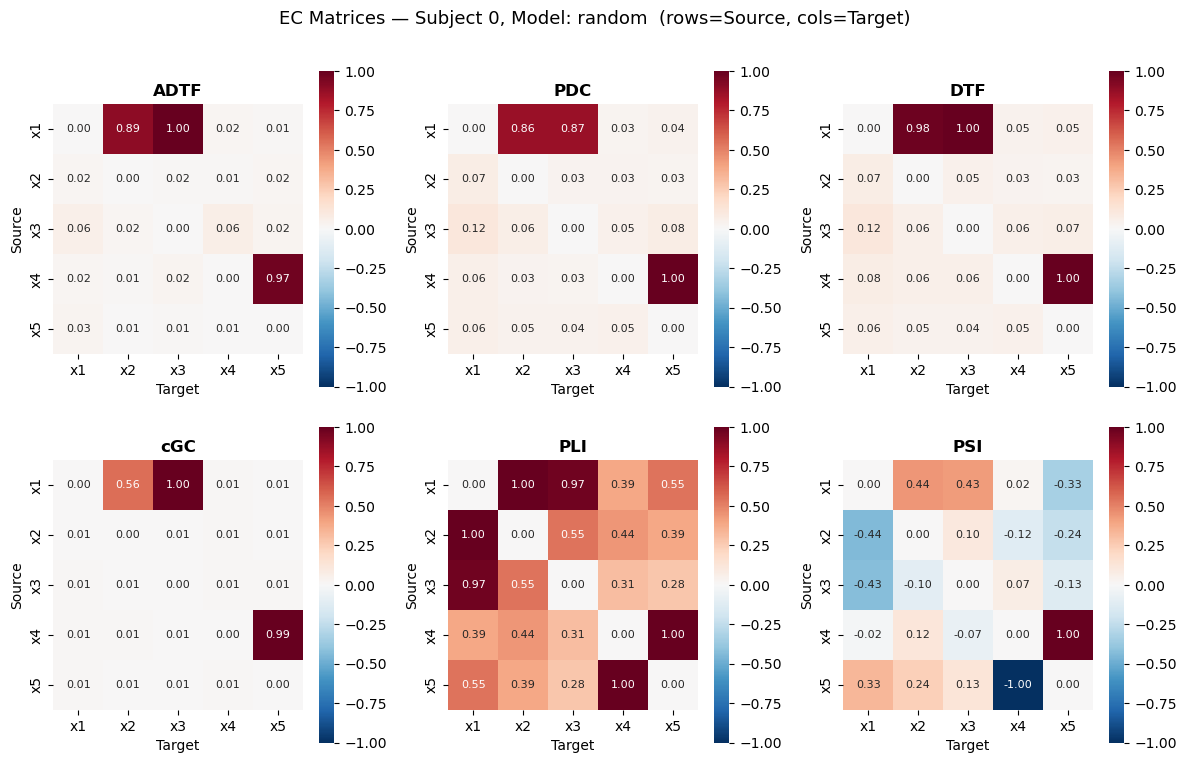

In [6]:
# ── Visualise EC matrices for the example (Subject 0, Model 0 = random) ───────
# Convention after fix: rows = Source, cols = Target  (matches GT[i,j] = i→j)
# Non-PSI methods store [target, source] → apply .T; PSI is already [source, target]
NODE_LABELS = [f'x{i+1}' for i in range(N_NODES)]

def maxabs_normalize(m):
    """Normalize off-diagonal to [-1, 1] by max absolute value (for display only)."""
    out = m.copy()
    np.fill_diagonal(out, 0)
    mask = ~np.eye(out.shape[0], dtype=bool)
    maxabs = np.nanmax(np.abs(out[mask]))
    if maxabs > 0:
        out[mask] = out[mask] / maxabs
    return out

methods_to_plot = [m for m in METHOD_NAMES if m not in ("TE", "MI")]
n_plot  = len(methods_to_plot)
n_cols  = 3
n_rows  = (n_plot + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.8))
axes = axes.flatten()

for i, method in enumerate(methods_to_plot):
    ax  = axes[i]
    res = results_example.get(method, {})
    if 'matrix' not in res:
        ax.set_visible(False)
        continue

    matrix = res['matrix'].copy()
    np.fill_diagonal(matrix, 0)
    # Transpose non-PSI to [source, target]
    display_matrix = matrix if method == 'PSI' else matrix.T
    display_matrix = maxabs_normalize(display_matrix)

    sns.heatmap(display_matrix, ax=ax, cmap='RdBu_r', vmin=-1, vmax=1,
                square=True, cbar=True, annot=True, fmt='.2f',
                annot_kws={'size': 8},
                xticklabels=NODE_LABELS,
                yticklabels=NODE_LABELS)
    ax.set_title(method, fontweight='bold')
    ax.set_xlabel('Target')
    ax.set_ylabel('Source')

for j in range(len(methods_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('EC Matrices — Subject 0, Model: random  (rows=Source, cols=Target)',
             fontsize=13, y=1.01)
plt.tight_layout()
savefig('fig7_benchmark_example_matrices')
plt.show()

## 3. Verify Methods Against Ground Truth (MCC)

Each model has a known binary causal structure (`ground_truth_dict`).  
We binarize predicted FC matrices and compute the **Matthews Correlation Coefficient (MCC)**.

In [7]:
# Ground-truth adjacency matrices are imported from the single source of truth.
# GT[source, target] = 1  means  channel (source+1) drives channel (target+1).
# See src/simulation/ground_truth.py for the full definitions.
ground_truth_dict = GROUND_TRUTH


In [8]:
# ── MCC computation ───────────────────────────────────────────────────────────
def compute_mcc(pred_matrix: np.ndarray, true_matrix: np.ndarray) -> float:
    """Binary MCC between predicted and ground-truth adjacency matrices."""
    return matthews_corrcoef(true_matrix.flatten(), pred_matrix.flatten())

In [9]:
# ── Full benchmark loop: all subjects × all models ────────────────────────────
# Convention: binarize in [source, target] space (GT[i,j] = i→j).
# Non-PSI methods return [target, source] → transpose before thresholding.
# PSI returns [source, target] → no transform needed.
mcc_dict = {model: {method: [] for method in METHOD_NAMES} for model in MODEL_NAMES}

for subj in tqdm(range(N_SUBJECTS), desc="Subjects"):
    for model_id, model_name in enumerate(MODEL_NAMES):
        data    = all_data[subj, model_id]       # shape: (epochs, nodes, time)
        fc      = FCMethods(data, fs=FS)
        results = fc.compute_all(METHODS_PARAMS)

        true_conn = ground_truth_dict[model_name]

        for method, result in results.items():
            if 'error' in result:
                mcc_dict[model_name][method].append(np.nan)
                continue

            if method in ("TE", "MI"):
                adj = result['result'].get_adjacency_matrix(
                    weights='max_te_lag', fdr=False)
                binary_conn = adj.edge_matrix.astype(int)
            else:
                conn = result['matrix'].copy()
                np.fill_diagonal(conn, 0)
                # Transpose to [source, target]; PSI is already [source, target]
                if method != 'PSI':
                    conn = conn.T
                off_diag = conn[~np.eye(N_NODES, dtype=bool)]
                threshold = np.nanpercentile(np.abs(off_diag), 75)
                binary_conn = (conn >= threshold).astype(int)
                np.fill_diagonal(binary_conn, 0)

            mcc = compute_mcc(binary_conn, true_conn)
            mcc_dict[model_name][method].append(mcc)

print("Done.")

Subjects: 100%|██████████| 25/25 [07:39<00:00, 18.38s/it]

Done.


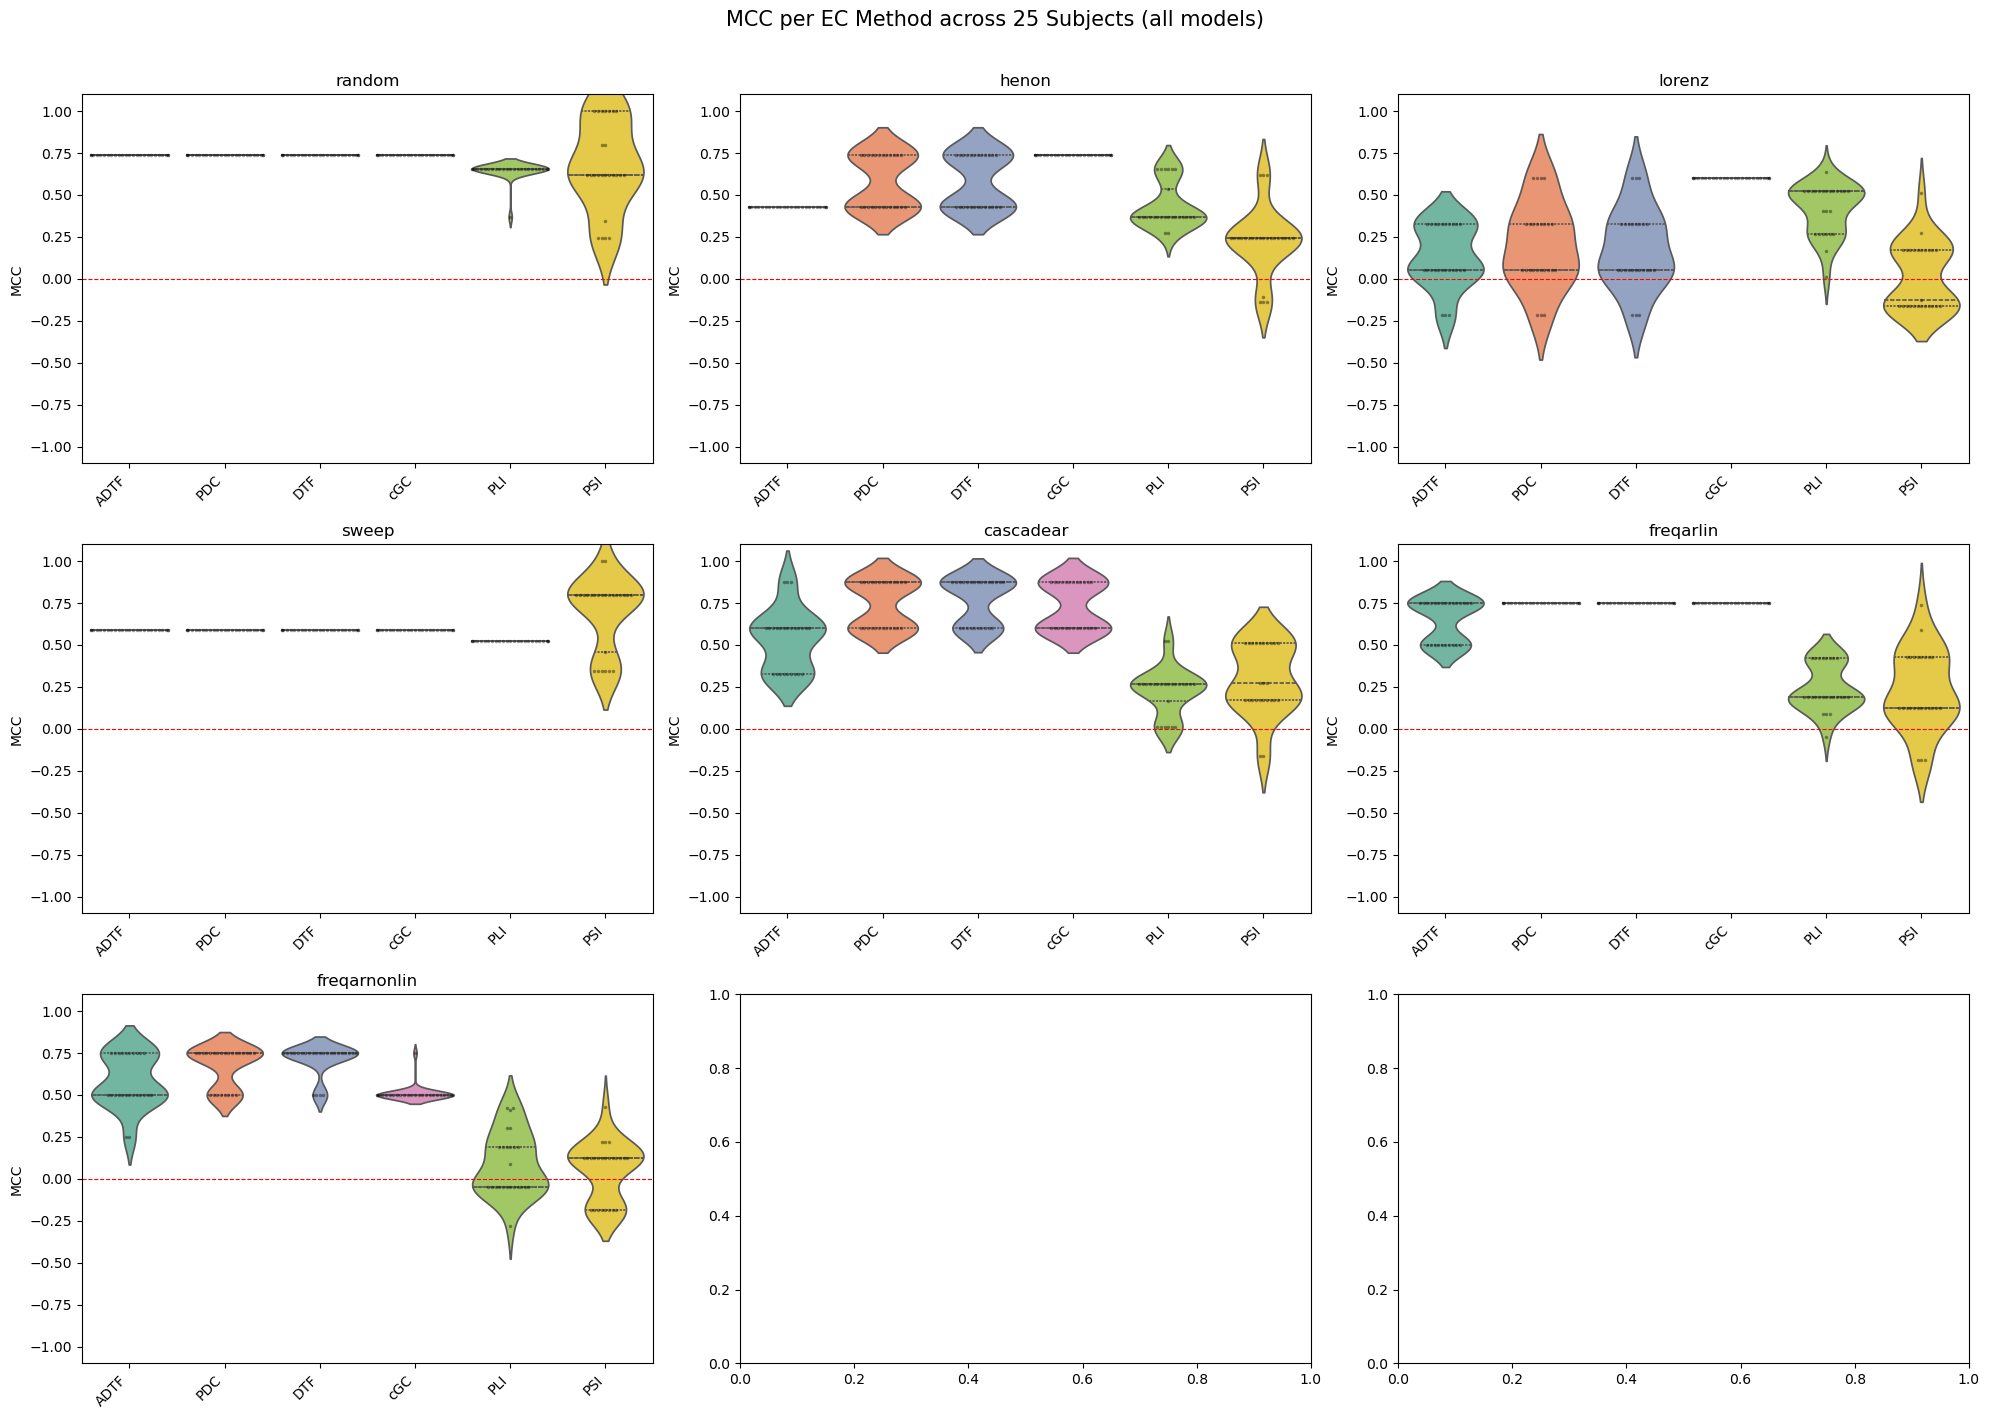

In [10]:
# ── Violin plot: MCC per method for each model ────────────────────────────────
from scipy.stats import ttest_1samp

n_models = len(MODEL_NAMES)
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for ax, model_name in zip(axes, MODEL_NAMES):
    mcc_vals = [mcc_dict[model_name][m] for m in METHOD_NAMES]

    sns.violinplot(data=mcc_vals, inner='quartile', palette='Set2', ax=ax)
    sns.swarmplot(data=mcc_vals, color='k', alpha=0.4, size=2.5, ax=ax)

    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='MCC=0')
    ax.set_xticks(range(len(METHOD_NAMES)))
    ax.set_xticklabels(METHOD_NAMES, rotation=45, ha='right')
    ax.set_ylabel("MCC")
    ax.set_ylim(-1.1, 1.1)
    ax.set_title(model_name)

plt.suptitle(f"MCC per EC Method across {N_SUBJECTS} Subjects (all models)",
             fontsize=15, y=1.01)
plt.tight_layout()
savefig('fig8_benchmark_mcc_violin')
plt.show()

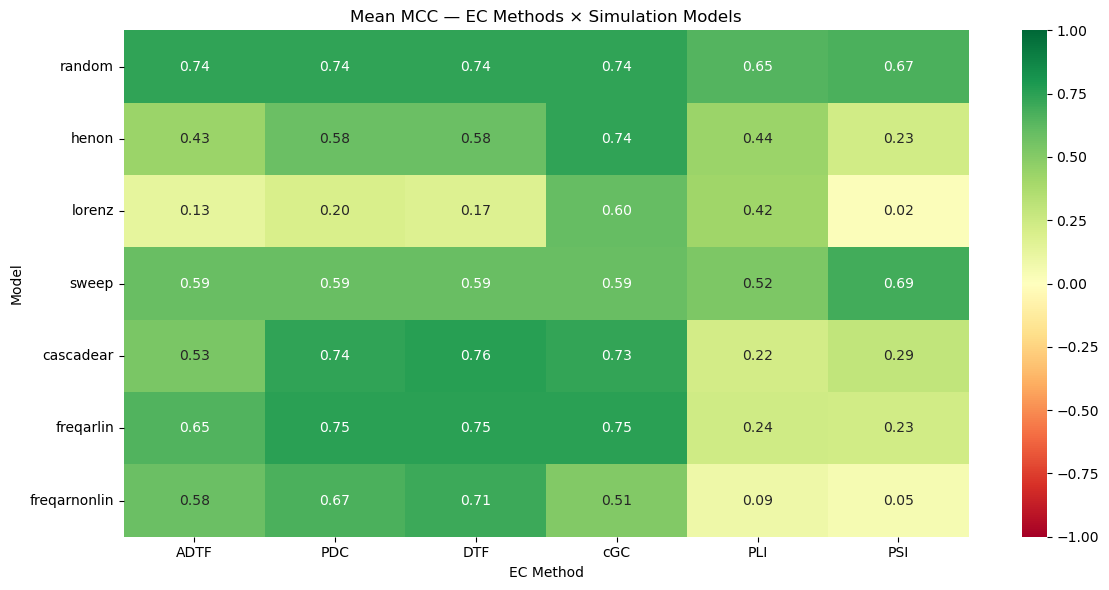

In [11]:
# ── Mean MCC heatmap: models × methods ────────────────────────────────────────
mean_mcc = np.array([
    [np.nanmean(mcc_dict[model][method]) for method in METHOD_NAMES]
    for model in MODEL_NAMES
])

plt.figure(figsize=(12, 6))
sns.heatmap(mean_mcc, annot=True, fmt=".2f", cmap='RdYlGn',
            vmin=-1, vmax=1, center=0,
            xticklabels=METHOD_NAMES,
            yticklabels=MODEL_NAMES)
plt.title("Mean MCC — EC Methods × Simulation Models")
plt.xlabel("EC Method")
plt.ylabel("Model")
plt.tight_layout()
savefig('fig9_benchmark_mean_mcc_heatmap')
plt.show()

In [12]:
# ── Save MCC results ──────────────────────────────────────────────────────────
mcc_save_path = os.path.join('..', 'data', 'mcc_benchmark.pkl')
with open(mcc_save_path, 'wb') as f:
    pickle.dump(mcc_dict, f)
print(f"MCC results saved to {mcc_save_path}")

MCC results saved to ../data/mcc_benchmark.pkl


## 4. Upgraded FC Utilities

Improvements over the original pipeline:
- **Adaptive thresholding** — percentile-based instead of fixed `max/2`
- **PSI sign convention** — corrected (positive = source drives target)
- **`binarize_fc()`** — unified binarization for all methods
- **`run_benchmark()`** — single-call benchmark for arbitrary subject/model subsets
- **`plot_mcc_summary()`** — combined heatmap + violin in one call

In [13]:
# ── Upgraded benchmark runner ─────────────────────────────────────────────────

def run_benchmark(
    all_data: np.ndarray,
    model_names: list,
    ground_truth_dict: dict,
    methods_params: dict,
    fs: float,
    n_subjects: int = None,
    model_subset: list = None,
    percentile: float = 75,
) -> dict:
    """
    Run all effective-connectivity methods on simulated data and compute MCC against ground truth.

    Parameters
    ----------
    all_data        : np.ndarray, shape (subjects, models, epochs, nodes, time)
    model_names     : list of model name strings (len = n_models)
    ground_truth_dict : dict mapping model_name → binary (n,n) adjacency matrix
    methods_params  : dict of {method_name: kwargs} passed to compute_all()
    fs              : sampling frequency in Hz
    n_subjects      : how many subjects to use (default: all)
    model_subset    : list of model names to include (default: all)
    percentile      : binarization threshold percentile

    Returns
    -------
    mcc_dict : {model_name: {method_name: [mcc_per_subject]}}
    """
    n_subj_total = all_data.shape[0]
    n_subjects   = n_subjects or n_subj_total
    model_subset = model_subset or model_names
    method_names = list(methods_params.keys())

    mcc_out = {m: {mt: [] for mt in method_names} for m in model_subset}

    for subj in tqdm(range(n_subjects), desc="Subjects"):
        for model_id, model_name in enumerate(model_names):
            if model_name not in model_subset:
                continue

            data    = all_data[subj, model_id]
            fc      = FCMethods(data, fs=fs)
            results = fc.compute_all(methods_params)
            true_conn = ground_truth_dict[model_name]

            for method, result in results.items():
                try:
                    binary = binarize_fc(result, method, percentile=percentile)
                    mcc    = compute_mcc(binary, true_conn)
                except Exception as e:
                    mcc = np.nan
                mcc_out[model_name][method].append(mcc)

    return mcc_out

In [14]:
# ── Upgraded summary plot ─────────────────────────────────────────────────────

def plot_mcc_summary(mcc_dict: dict, method_names: list, title: str = "", save_name: str | None = None):
    """
    Side-by-side: mean MCC heatmap + per-model violin plots.

    Parameters
    ----------
    mcc_dict     : {model_name: {method_name: [mcc values]}}
    method_names : ordered list of method names
    title        : figure suptitle
    save_name    : optional output filename stem under figures/
    """
    model_names = list(mcc_dict.keys())

    # -- Mean MCC heatmap --
    mean_mcc = np.array([
        [np.nanmean(mcc_dict[model][method]) for method in method_names]
        for model in model_names
    ])

    fig, axes = plt.subplots(1, 2, figsize=(22, max(5, len(model_names) * 0.9)))

    sns.heatmap(mean_mcc, annot=True, fmt=".2f", cmap='RdYlGn',
                vmin=-1, vmax=1, center=0,
                xticklabels=method_names,
                yticklabels=model_names,
                ax=axes[0])
    axes[0].set_title("Mean MCC")
    axes[0].set_xlabel("EC Method")
    axes[0].set_ylabel("Model")

    # -- Mean MCC line plot per model --
    for model_name in model_names:
        means = [np.nanmean(mcc_dict[model_name][m]) for m in method_names]
        axes[1].plot(method_names, means, marker='o', label=model_name)

    axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel("Mean MCC")
    axes[1].set_xlabel("EC Method")
    axes[1].set_title("Mean MCC per Model")
    axes[1].legend(loc='lower right', fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)

    if title:
        fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    if save_name:
        savefig(save_name)
    plt.show()

Subjects: 100%|██████████| 25/25 [06:50<00:00, 16.40s/it]


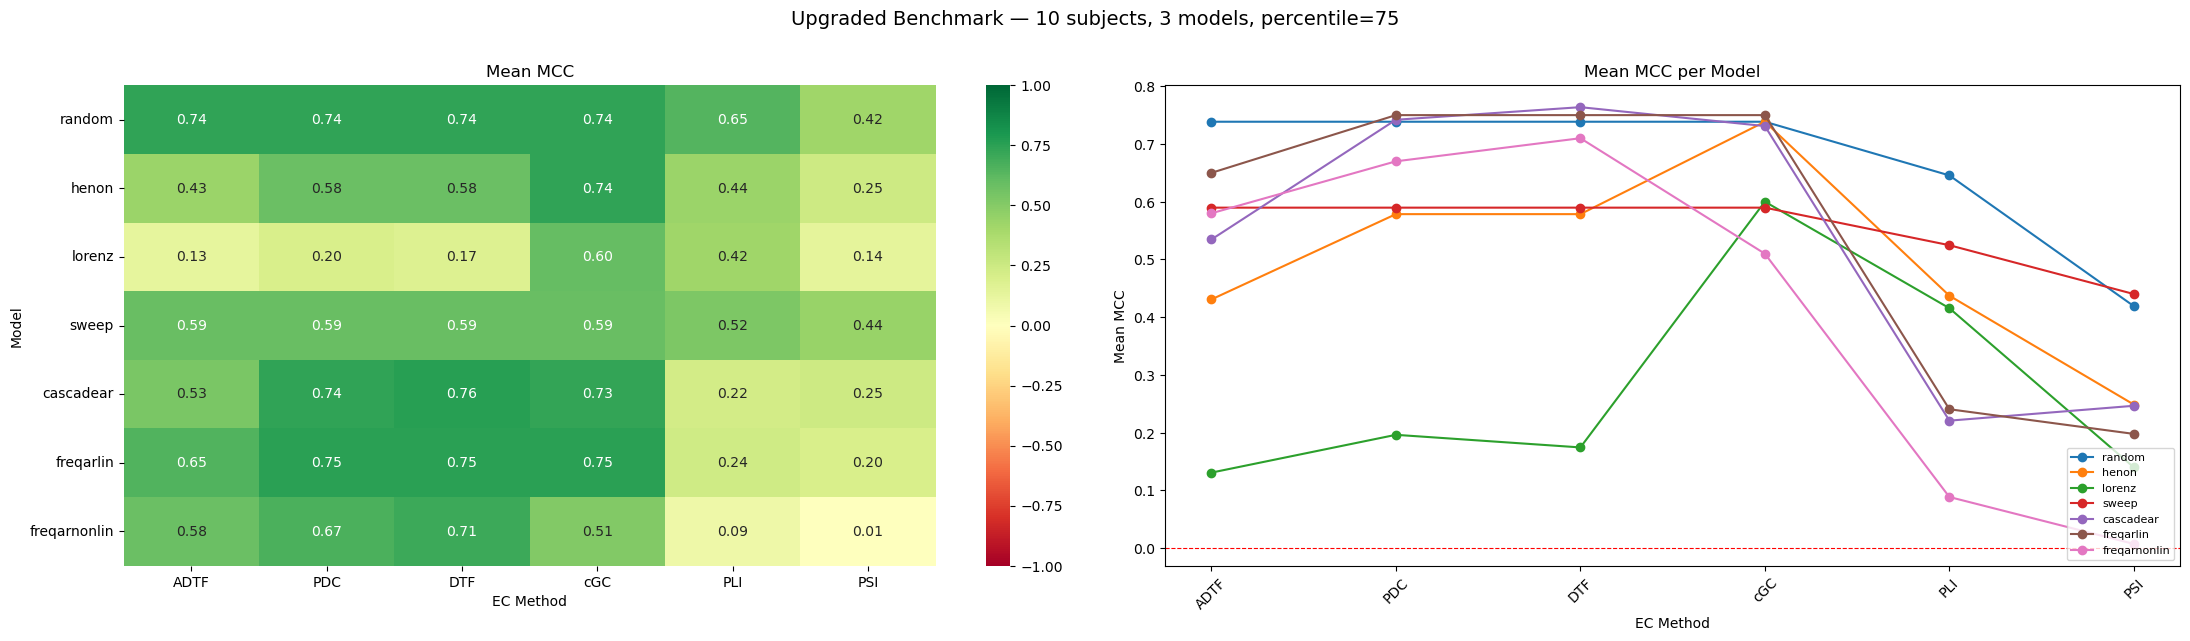

In [15]:
# ── Example: run upgraded benchmark on a subset ───────────────────────────────
mcc_upgraded = run_benchmark(
    all_data          = all_data,
    model_names       = MODEL_NAMES,
    ground_truth_dict = ground_truth_dict,
    methods_params    = METHODS_PARAMS,
    fs                = FS,
    n_subjects        = 25,                          # quick test: 10 subjects
    model_subset      = MODEL_NAMES, #['random', 'henon', 'lorenz'],
    percentile        = 75,
)

plot_mcc_summary(
    mcc_upgraded,
    method_names = METHOD_NAMES,
    title        = "Upgraded Benchmark — 10 subjects, 3 models, percentile=75",
    save_name    = "fig10_benchmark_summary"
)